# Next-value forecasting with an LSTM

This notebook builds a small many-to-one forecasting model. Each sample contains 10 consecutive values from a noisy, amplitude-modulated cosine wave, and the model predicts the value immediately after that window.

## Imports and reproducibility

NumPy creates the synthetic series, PyTorch supplies the dataset and LSTM, and Seaborn/Matplotlib display the results. Fixed seeds make the generated data and initial model weights repeatable.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset

np.random.seed(42)
torch.manual_seed(42)

## Create the time series

The base signal is a cosine wave. Its amplitude grows slowly over time, and Gaussian noise prevents the pattern from being perfectly smooth. The model will receive only past signal values, not the original angle values.

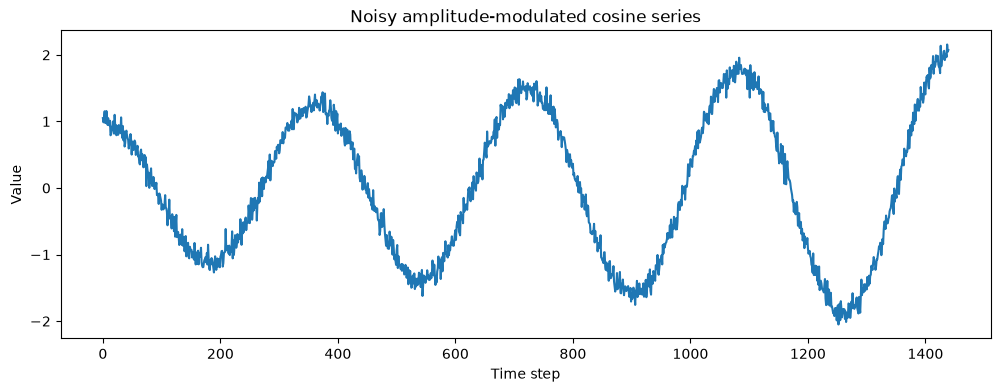

In [2]:
num_points = 360 * 4
X = np.arange(num_points)

y = (
    np.cos(X * np.pi / 180) * (1 + X / num_points)
    + np.random.randn(num_points) * 0.1
)

plt.figure(figsize=(12, 4))
sns.lineplot(x=X, y=y)
plt.title("Noisy amplitude-modulated cosine series")
plt.xlabel("Time step")
plt.ylabel("Value")
plt.show()

## Build sliding windows

Each input sample is a window of 10 consecutive values. Its target is the next value:

- first sample: `y[0:10]` predicts `y[10]`
- second sample: `y[1:11]` predicts `y[11]`

Sliding the window by one position creates 1,430 input-target pairs from the 1,440-point series.

In [3]:
sequence_length = 10
X_restruct = []
y_restruct = []

for index in range(num_points - sequence_length):
    X_restruct.append(y[index:index + sequence_length])
    y_restruct.append(y[index + sequence_length])

X_restruct = np.array(X_restruct)
y_restruct = np.array(y_restruct)

print("Input windows:", X_restruct.shape)
print("Targets:", y_restruct.shape)

Input windows: (1430, 10)
Targets: (1430,)


## Split in time order

The first 1,080 windows are used for training and the remaining 350 for testing. A time-series split keeps future observations out of the training set.

In [4]:
train_test_clipping = 360 * 3

X_train = X_restruct[:train_test_clipping]
X_test = X_restruct[train_test_clipping:]
y_train = y_restruct[:train_test_clipping]
y_test = y_restruct[train_test_clipping:]

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test: ", X_test.shape, "y_test: ", y_test.shape)

X_train: (1080, 10) y_train: (1080,)
X_test:  (350, 10) y_test:  (350,)


## Dataset and DataLoader

The dataset converts NumPy arrays to `float32` tensors. The training loader returns two windows at a time, so one input batch has shape `(2, 10)` and one target batch has shape `(2,)`. The test loader returns all 350 test windows together.

In [5]:
class TrigonometricDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.y[index]


train_dataset = TrigonometricDataset(X_train, y_train)
test_dataset = TrigonometricDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=len(test_dataset), shuffle=False)

sample_X, sample_y = next(iter(train_loader))
print("Training batch:", sample_X.shape, sample_y.shape)

Training batch: torch.Size([2, 10]) torch.Size([2])


## Training portion of the series

The model learns from the first three cycles. The final portion remains unseen until evaluation.

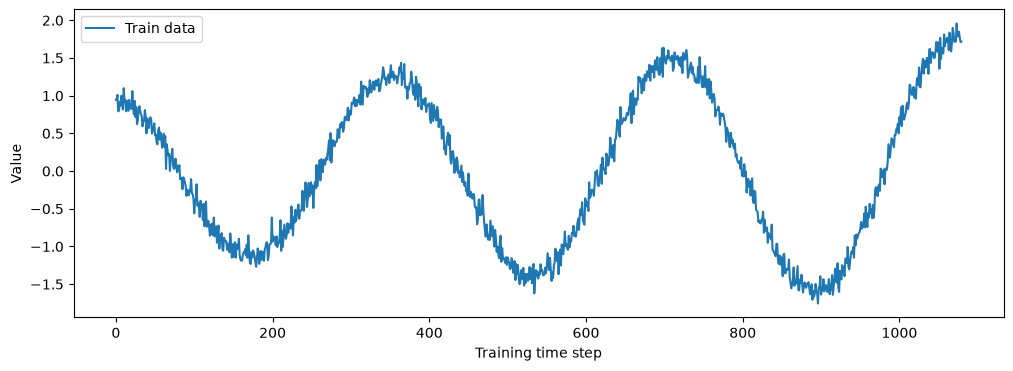

In [6]:
plt.figure(figsize=(12, 4))
sns.lineplot(x=range(len(y_train)), y=y_train, label="Train data")
plt.xlabel("Training time step")
plt.ylabel("Value")
plt.show()

## LSTM model

The LSTM reads one value at each of 10 time steps. `input_size=1` means one feature per step; it does not mean one time step.

At every step, the LSTM updates a hidden summary and a longer-term memory. `hidden_size=5` means each of those states contains five learned values. PyTorch returns a five-value hidden summary for every time step, giving `(batch, 10, 5)`. For next-value forecasting, only the final summary has processed the complete window, so `lstm_output[:, -1, :]` selects `(batch, 5)`.

![LSTM cell internals and sequence flow](assets/lstm_cell_internal_flow.png)

The linear layer maps those five learned values to one next-value prediction. There is no ReLU because the cosine target can be negative. Hidden size is a capacity setting: try small values such as 4, 8, 16, or 32 and select one using validation loss.

Typical task heads are simple:

- regression: linear layer plus MSE or a similar regression loss
- binary classification: one output plus `BCEWithLogitsLoss`
- single-label multiclass classification: one output per class plus `CrossEntropyLoss`
- multi-label classification: one output per label plus `BCEWithLogitsLoss`

In [7]:
class TrigonometryModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=5, output_size=1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
        )
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        lstm_output, _ = self.lstm(x)
        final_summary = lstm_output[:, -1, :]
        return self.output(final_summary)

## Check the model contract

This random batch is only a shape check. Unlike `X_train`, it already includes the final feature dimension. Two input windows should produce two predictions.

In [8]:
model = TrigonometryModel()
dummy_input = torch.rand((2, sequence_length, 1))
dummy_output = model(dummy_input)

print("Dummy input: ", dummy_input.shape)
print("Model output:", dummy_output.shape)

Dummy input: 

 torch.Size([2, 10, 1])
Model output: torch.Size([2, 1])


## Tensor dimensions during training

The feature axis is added before the LSTM. The target is reshaped separately so it matches the model output when MSE is calculated.

![Training tensor dimension flow](assets/lstm_training_dimensions.png)

## Loss and optimizer

MSE measures the average squared distance between predicted and actual next values. Adam updates both the LSTM and linear-layer parameters.

In [9]:
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
num_epochs = 200

## Train the model

Each `(batch, 10)` input becomes `(batch, 10, 1)` so the LSTM can distinguish time steps from features. Each `(batch,)` target becomes `(batch, 1)` to match the predictions.

In [10]:
loss_history = []
model.train()

for epoch in range(num_epochs):
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()

        lstm_input = X_batch.reshape(-1, sequence_length, 1)
        predictions = model(lstm_input)
        targets = y_batch.reshape(-1, 1)

        loss = loss_function(predictions, targets)
        loss.backward()
        optimizer.step()

    loss_history.append(loss.item())
    if epoch % 50 == 0:
        print(f"Epoch: {epoch:3d}, Loss: {loss.item():.6f}")

Epoch:   0, Loss: 1.729167


Epoch:  50, Loss: 0.002445


Epoch: 100, Loss: 0.003711


Epoch: 150, Loss: 0.006568


## Tensor dimensions during prediction

The full test set is one batch. `squeeze(1)` removes only the one-value output axis, leaving one prediction for each of the 350 windows.

![Prediction tensor dimension flow](assets/lstm_prediction_dimensions.png)

In [11]:
X_test_torch, y_test_torch = next(iter(test_loader))

model.eval()
with torch.no_grad():
    test_input = X_test_torch.reshape(-1, sequence_length, 1)
    y_pred = model(test_input).squeeze(1).cpu().numpy()

y_actual = y_test_torch.cpu().numpy()
test_mse = np.mean((y_actual - y_pred) ** 2)

print("Test input: ", X_test_torch.shape, "->", test_input.shape)
print("Predictions:", y_pred.shape)
print(f"Test MSE: {test_mse:.6f}")

Test input:  torch.Size([350, 10]) -> torch.Size([350, 10, 1])
Predictions: (350,)
Test MSE: 0.019720


## Actual and predicted values

The line plot checks whether the forecast follows the held-out wave, including its negative half-cycles.

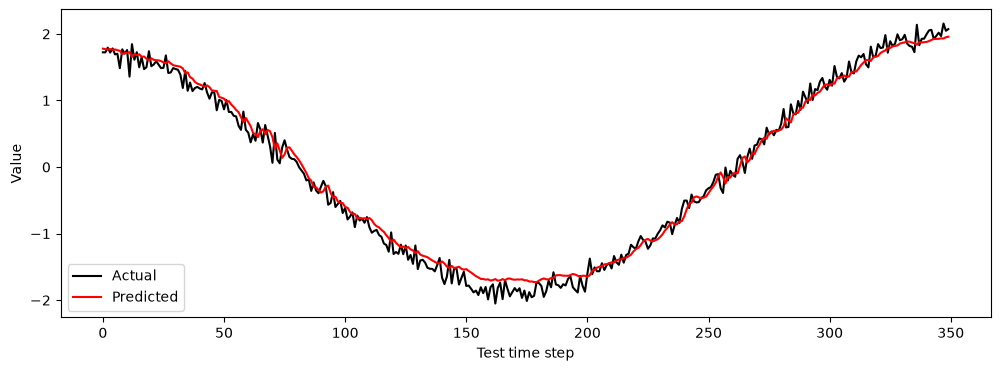

In [12]:
test_steps = range(len(y_actual))

plt.figure(figsize=(12, 4))
sns.lineplot(x=test_steps, y=y_actual, label="Actual", color="black")
sns.lineplot(x=test_steps, y=y_pred, label="Predicted", color="red")
plt.xlabel("Test time step")
plt.ylabel("Value")
plt.show()

## Prediction agreement

Points near a rising diagonal indicate that predictions and actual values move together. Large deviations show where the model misses the target.

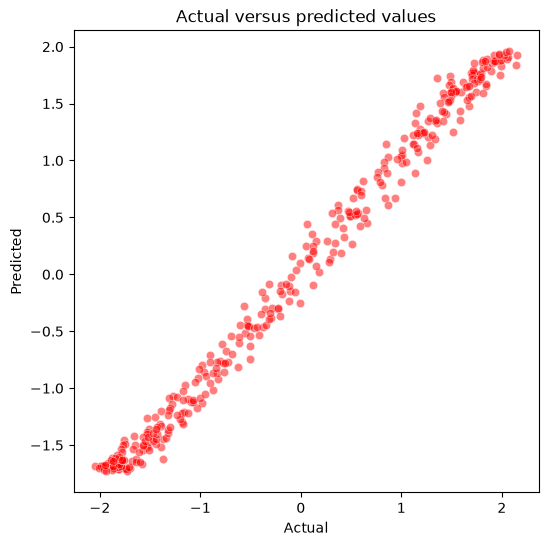

In [13]:
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_actual, y=y_pred, color="red", alpha=0.5)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual versus predicted values")
plt.show()